# <center>**Tecnológico de Costa Rica**</center>

***IC-6200 / Inteligencia artificial***

Profesor

*   **Efren Jimenez Delgado**

Proyecto JarvisTEC, I Semestre 2026

## Análisis del Problema

Queremos estimar el **precio de cierre de una acción del S&P 500** (Apple, Microsoft, Amazon o Google) para la sesión de bolsa siguiente y hasta siete sesiones después del último dato. Es un problema de **regresión sobre series de tiempo**, una por símbolo, con un modelo compartido que predice el retorno logarítmico del día siguiente.

Igual que con el Bitcoin, la referencia obligada es la **persistencia** ("mañana = hoy"). La hipótesis de los mercados eficientes en su forma débil (Fama, 1970) dice que el historial de precios no permite predecir los siguientes, y los retornos de los activos tienen regularidades conocidas: colas pesadas, casi ninguna autocorrelación del signo y agrupamiento de la volatilidad (Cont, 2001).

Los datos terminan el 7 de febrero de 2018: "mañana" es el 8 de febrero y el modelo no conoce el precio actual.

# Caso Aplicado: Acciones del S&P 500
## Varias series de tiempo, un modelo compartido y comparación contra la persistencia y la deriva

---

**Temas:** Series de tiempo en panel · Retornos logarítmicos · Predicción recursiva · Validación por fechas · Bootstrap de días completos  
**Herramientas:** Python · Pandas · Scikit-learn · Seaborn

---

### El hilo conductor

| Etapa | Pregunta central |
|---|---|
| 1 — Entendimiento | ¿Cómo vienen los datos de los cuatro símbolos y comparten el calendario? |
| 2 — Exploración | ¿Cómo se parecen y en qué se diferencian los retornos de los símbolos? |
| 3 — Modelo | ¿Un solo modelo para los cuatro supera a repetir el último precio o a la tendencia media? |
| 4 — Evaluación | ¿La ventaja, si la hay, viene de aprender algo o solo de la deriva? |

> Nota: los símbolos están correlacionados, así que las filas de un mismo día no son independientes. Por eso la validación cruzada agrupa los cuatro símbolos de cada día y el bootstrap remuestrea días completos.

Este notebook es un extra del modelo 10 del proyecto: reproduce de forma didáctica el entrenamiento que hace `train.py` y se puede probar en Google Colab. No reemplaza al código del repositorio.

### Autores

   * Equipo JarvisTEC (proyecto de la primera etapa)

### Librerías

In [1]:
# Manejo de datasets
import pandas as pd
import numpy as np
# Gráficos
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
# Modelos
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
# Ignorar Warnings
import warnings
warnings.filterwarnings('ignore')

SEMILLA = 42

---
# Sección 1: Entendimiento de los Datos
---

## Entendimiento de los Datos

Se usa un recorte del conjunto *all_stocks_5yr* de Kaggle (Nugent, 2018) con cuatro símbolos: AAPL (Apple), MSFT (Microsoft), AMZN (Amazon) y GOOGL (Google). El conjunto completo tiene 505 símbolos, pero pesa unos 30 MB y no se usa aquí.

- date   : fecha de la sesión
- open, high, low, close : precios de apertura, máximo, mínimo y cierre en dólares
- volume : volumen negociado
- Name   : símbolo de la acción

Los datos están en el archivo `dataset.csv` de la carpeta `backend/features/modelo_10_sp500/` del repositorio. Son 5 036 filas y 7 columnas.

En Colab hay dos formas de usarlo: arrastrarlo al panel de archivos (queda en `sample_data/`) o subirlo cuando la celda lo pida.

In [2]:
# Ubicar el archivo de datos (Colab o ejecución local)
import os

RUTA = next((r for r in ("sample_data/dataset.csv", "dataset.csv") if os.path.exists(r)), None)
if RUTA is None:
    try:
        from google.colab import files
        print("Seleccione el archivo dataset.csv")
        RUTA = next(iter(files.upload()))
    except ImportError:
        raise FileNotFoundError("No se encontró dataset.csv: colóquelo en sample_data/ o en la carpeta actual")
print("Archivo de datos:", RUTA)

Archivo de datos: sample_data/dataset.csv


In [3]:
# Cargar los datos
datos = pd.read_csv(RUTA, parse_dates=["date"])
datos.head()

,date,open,high,low,close,volume,Name
0,2013-02-08,67.7142,68.4014,66.8928,67.8542,158168416,AAPL
1,2013-02-11,68.0714,69.2771,67.6071,68.5614,129029425,AAPL
2,2013-02-12,68.5014,68.9114,66.8205,66.8428,151829363,AAPL
3,2013-02-13,66.7442,67.6628,66.1742,66.7156,118721995,AAPL
4,2013-02-14,66.3599,67.3771,66.2885,66.6556,88809154,AAPL


In [4]:
# Información del dataset
datos.info()

<class 'pandas.DataFrame'>
RangeIndex: 5036 entries, 0 to 5035
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    5036 non-null   datetime64[us]
 1   open    5036 non-null   float64       
 2   high    5036 non-null   float64       
 3   low     5036 non-null   float64       
 4   close   5036 non-null   float64       
 5   volume  5036 non-null   int64         
 6   Name    5036 non-null   str           
dtypes: datetime64[us](1), float64(4), int64(1), str(1)
memory usage: 275.5 KB


In [5]:
df = datos.rename(columns={"date": "fecha", "Name": "simbolo", "close": "cierre", "open": "apertura", "high": "maximo", "low": "minimo", "volume": "volumen"})
df = df.sort_values(["simbolo", "fecha"]).reset_index(drop=True)
SIMBOLOS = sorted(df["simbolo"].unique())

print("Filas:", len(df), " Símbolos:", SIMBOLOS, " Fechas:", df["fecha"].nunique())
print("Rango:", df["fecha"].min().date(), "a", df["fecha"].max().date())
print("Filas por símbolo:", df["simbolo"].value_counts().sort_index().to_dict())
print("Nulos:", int(df.isna().sum().sum()), " Duplicados (fecha, símbolo):", int(df.duplicated(["fecha", "simbolo"]).sum()))
fechas = [g["fecha"].tolist() for _, g in df.groupby("simbolo")]
print("Los cuatro símbolos comparten exactamente las mismas fechas:", all(f == fechas[0] for f in fechas))
print("Días naturales entre sesiones:", df[df["simbolo"] == "AAPL"]["fecha"].diff().dt.days.value_counts().sort_index().to_dict())
df.groupby("simbolo")["cierre"].describe().round(2)

Filas: 5036  Símbolos: ['AAPL', 'AMZN', 'GOOGL', 'MSFT']  Fechas: 1259
Rango: 2013-02-08 a 2018-02-07
Filas por símbolo: {'AAPL': 1259, 'AMZN': 1259, 'GOOGL': 1259, 'MSFT': 1259}
Nulos: 0  Duplicados (fecha, símbolo): 0
Los cuatro símbolos comparten exactamente las mismas fechas: True
Días naturales entre sesiones: {1.0: 986, 2.0: 11, 3.0: 227, 4.0: 34}


,count,mean,std,min,25%,50%,75%,max
simbolo,,,,,,,,
AAPL,1259.0,109.07,30.56,55.79,84.83,109.01,127.12,179.26
AMZN,1259.0,576.88,282.50,248.23,325.80,503.82,777.42,1450.89
GOOGL,1259.0,682.23,187.57,383.34,543.02,652.47,806.40,1187.56
MSFT,1259.0,51.06,14.85,27.37,40.31,47.52,59.73,95.01


Hay un registro por cada **día hábil**, no por día natural: los saltos de 3 días son fines de semana y los de 4 son feriados con fin de semana. Los precios tienen escalas muy distintas (de unos 50 a más de 1 400 dólares), así que el modelo trabajará con retornos, que no dependen de la escala.

Igual que con el Bitcoin, se excluyen la apertura, el máximo, el mínimo y el volumen: no se pueden predecir para encadenar la predicción recursiva y no se conocen al consultar.

---
# Sección 2: Exploración de los Datos
---

## Exploración de los Datos

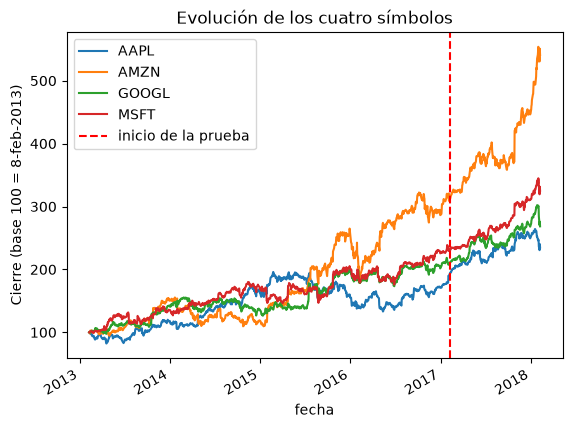

Multiplicador en todo el período: {'AAPL': 2.35, 'AMZN': 5.41, 'GOOGL': 2.68, 'MSFT': 3.25}
Variación dentro de la prueba: {'AAPL': 0.21, 'AMZN': 0.73, 'GOOGL': 0.27, 'MSFT': 0.41}


In [6]:
base = df.pivot(index="fecha", columns="simbolo", values="cierre")
(100 * base / base.iloc[0]).plot()
corte = int(len(base) * 0.8)
plt.axvline(base.index[corte], color="red", linestyle="--", label="inicio de la prueba")
plt.legend()
plt.ylabel("Cierre (base 100 = 8-feb-2013)")
plt.title("Evolución de los cuatro símbolos")
plt.show()
print("Multiplicador en todo el período:", (base.iloc[-1] / base.iloc[0]).round(2).to_dict())
print("Variación dentro de la prueba:", (base.iloc[-1] / base.iloc[corte] - 1).round(2).to_dict())

Los cuatro precios suben de forma sostenida y las series se mueven juntas. La prueba es un tramo alcista y, salvo el final, tranquilo.

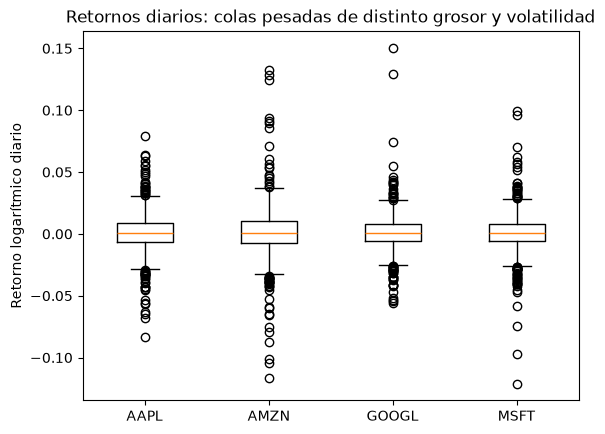

,media,desviación,curtosis en exceso
simbolo,,,
AAPL,0.0007,0.0146,3.8194
AMZN,0.0013,0.0181,11.0572
GOOGL,0.0008,0.0137,18.6748
MSFT,0.0009,0.0142,11.1694


In [7]:
retornos = np.log(df["cierre"]).groupby(df["simbolo"]).diff()
ret = retornos.to_frame("r").assign(fecha=df["fecha"], simbolo=df["simbolo"]).pivot(index="fecha", columns="simbolo", values="r").dropna()

plt.boxplot([ret[s] for s in SIMBOLOS], tick_labels=SIMBOLOS)
plt.ylabel("Retorno logarítmico diario")
plt.title("Retornos diarios: colas pesadas de distinto grosor y volatilidad")
plt.show()
pd.DataFrame({"media": ret.mean(), "desviación": ret.std(), "curtosis en exceso": ret.kurt()}).round(4)

Los retornos de los cuatro símbolos tienen colas pesadas, aunque de distinto grosor, y volatilidades diferentes: Amazon es la más volátil.

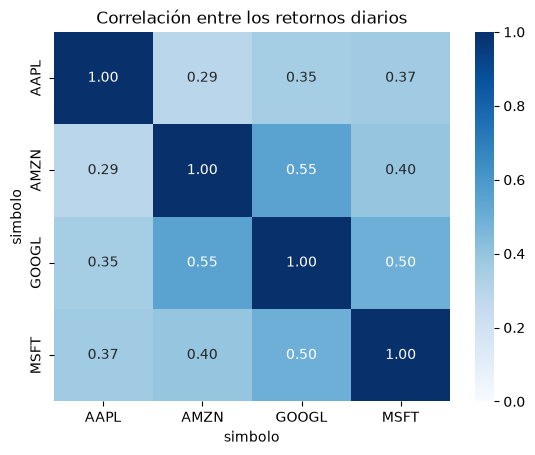

In [8]:
sns.heatmap(ret.corr(), annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1)
plt.title("Correlación entre los retornos diarios")
plt.show()

Los retornos de los símbolos están **correlacionados** (en una banda de 0.3 a 0.55). Esto importa para la evaluación: las filas de un mismo día no son independientes.

> Analogía: es como preguntar la opinión de cuatro vecinos que leyeron el mismo periódico. Son cuatro respuestas, pero casi no son cuatro datos independientes.

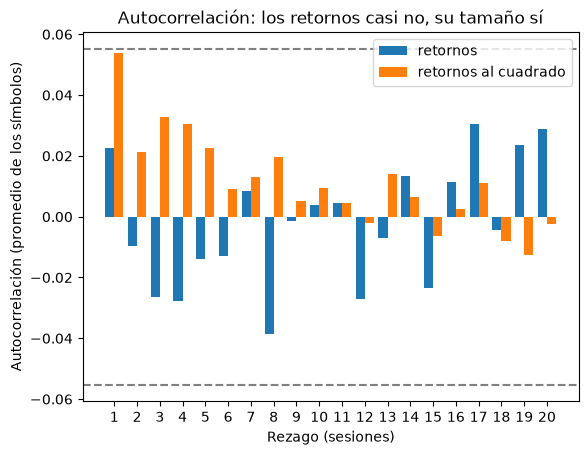

Retornos, rezagos 1 a 5: [ 0.022 -0.01  -0.026 -0.028 -0.014] | cota del 95 %: +-0.055
Retornos al cuadrado, rezagos 1 a 5: [0.054 0.021 0.033 0.031 0.023]
El precio sube en el 52.6 % de las sesiones


In [9]:
def autocorrelacion(x, rezagos=20):
    x = np.asarray(x, dtype=float) - np.mean(x)
    return np.array([np.sum(x[k:] * x[:-k]) / np.sum(x ** 2) for k in range(1, rezagos + 1)])

rezagos = np.arange(1, 21)
medio = np.mean([autocorrelacion(ret[s].to_numpy()) for s in SIMBOLOS], axis=0)
medio_cuadrado = np.mean([autocorrelacion(ret[s].to_numpy() ** 2) for s in SIMBOLOS], axis=0)
cota = 1.96 / np.sqrt(len(ret))
plt.bar(rezagos - 0.2, medio, width=0.4, label="retornos")
plt.bar(rezagos + 0.2, medio_cuadrado, width=0.4, label="retornos al cuadrado")
plt.axhline(cota, color="gray", linestyle="--")
plt.axhline(-cota, color="gray", linestyle="--")
plt.xticks(rezagos)
plt.xlabel("Rezago (sesiones)")
plt.ylabel("Autocorrelación (promedio de los símbolos)")
plt.legend()
plt.title("Autocorrelación: los retornos casi no, su tamaño sí")
plt.show()
print("Retornos, rezagos 1 a 5:", medio[:5].round(3), "| cota del 95 %%: +-%.3f" % cota)
print("Retornos al cuadrado, rezagos 1 a 5:", medio_cuadrado[:5].round(3))
print("El precio sube en el %.1f %% de las sesiones" % (100 * (ret.to_numpy() > 0).mean()))

La autocorrelación de los retornos queda dentro de la cota del 95 %, y la de los retornos al cuadrado es positiva pero mucho menor que en el Bitcoin: hay algo de agrupamiento de volatilidad.

---
# Sección 3: Ajuste del Modelo
---

## Modelo de Machine Learning

### Variables construidas

Las mismas del modelo del Bitcoin, calculadas **solo con cierres pasados de cada símbolo**: retornos de 1 a 5, 7 y 30 días, distancia a la media móvil de 7 y 30 días y desviación de los retornos de 7 y 30 días. Como son retornos, no dependen de la escala y **un único modelo sirve a los cuatro símbolos**. El símbolo solo determina el precio de partida y la volatilidad del intervalo.

In [10]:
VENTANA_MINIMA = 31
CARACTERISTICAS = ["ret_1", "ret_2", "ret_3", "ret_4", "ret_5", "ret_7", "ret_30", "dist_media_7", "dist_media_30", "vol_7", "vol_30"]

def caracteristicas(cierres):
    c = pd.Series(np.asarray(cierres, dtype=float))
    lc = np.log(c)
    r = lc.diff()
    return pd.DataFrame({
        "ret_1": r, "ret_2": r.shift(1), "ret_3": r.shift(2), "ret_4": r.shift(3), "ret_5": r.shift(4),
        "ret_7": lc - lc.shift(7), "ret_30": lc - lc.shift(30),
        "dist_media_7": lc - np.log(c.rolling(7).mean()), "dist_media_30": lc - np.log(c.rolling(30).mean()),
        "vol_7": r.rolling(7).std(), "vol_30": r.rolling(30).std(),
    })[CARACTERISTICAS]

cierres = {s: g["cierre"].to_numpy(dtype=float) for s, g in df.groupby("simbolo", sort=True)}
bloques_x, bloques_y = [], []
for s, c_s in cierres.items():
    Xs = caracteristicas(c_s)
    ys = pd.Series(np.log(c_s)).diff().shift(-1)           # retorno de la sesión siguiente
    validas = Xs.notna().all(axis=1) & ys.notna()
    Xs, ys = Xs[validas], ys[validas]
    Xs.index = ys.index = pd.MultiIndex.from_product([[s], Xs.index], names=["simbolo", "posicion"])
    bloques_x.append(Xs)
    bloques_y.append(ys)
X, y = pd.concat(bloques_x), pd.concat(bloques_y)
print("Filas (símbolo, día):", len(X))

Filas (símbolo, día): 4912


### Partición temporal

Los últimos 252 días (20 %) son la prueba y los cuatro símbolos se cortan en la misma fecha. Ningún objetivo de entrenamiento cae dentro de la prueba.

In [11]:
n = len(next(iter(cierres.values())))
corte = int(n * 0.8)
posicion = X.index.get_level_values("posicion").to_numpy()
i_entrena = np.flatnonzero(posicion <= corte - 2)      # su objetivo cae antes del corte
X_train, y_train = X.iloc[i_entrena], y.iloc[i_entrena]
fechas_u = df[df["simbolo"] == "AAPL"]["fecha"].reset_index(drop=True)
print("Entrenamiento:", len(X_train), "filas hasta", fechas_u[corte - 1].date(), "| prueba desde", fechas_u[corte].date(), "(%d días)" % (n - corte))

Entrenamiento: 3904 filas hasta 2017-02-07 | prueba desde 2017-02-08 (252 días)


### Candidatos y validación cruzada por fechas

Las dos líneas base (persistencia y deriva) no pueden ser elegidas. En la validación cruzada de ventana creciente se agrupan los cuatro símbolos de cada día, porque están correlacionados (Bergmeir y Benítez, 2012).

In [12]:
def armar(estimador, escalar=False):
    return Pipeline([("escala", StandardScaler() if escalar else "passthrough"), ("modelo", estimador)])

def candidatos():
    return {
        "persistencia (línea base)": armar(DummyRegressor(strategy="constant", constant=0.0)),
        "deriva (línea base)": armar(DummyRegressor(strategy="mean")),
        "ridge": armar(RidgeCV(alphas=np.logspace(-1, 5, 25)), escalar=True),
        "random forest": armar(RandomForestRegressor(n_estimators=200, min_samples_leaf=50, max_depth=6, random_state=SEMILLA, n_jobs=-1)),
        "gradient boosting": armar(HistGradientBoostingRegressor(max_iter=100, learning_rate=0.03, max_depth=3, min_samples_leaf=50,
                                                                 early_stopping=False, random_state=SEMILLA)),
    }

pos_train = X_train.index.get_level_values("posicion").to_numpy()
dias = np.sort(np.unique(pos_train))
pliegues = [(np.flatnonzero(np.isin(pos_train, dias[e])), np.flatnonzero(np.isin(pos_train, dias[p]))) for e, p in TimeSeriesSplit(n_splits=5).split(dias)]

filas = {}
for nombre, pipe in candidatos().items():
    rmse = -cross_val_score(pipe, X_train, y_train, cv=pliegues, scoring="neg_root_mean_squared_error")
    filas[nombre] = {"RMSE del retorno diario (cv)": rmse.mean(), "desviación": rmse.std()}
comparacion = pd.DataFrame(filas).T.round(5)
comparacion

,RMSE del retorno diario (cv),desviación
persistencia (línea base),0.01587,0.00236
deriva (línea base),0.01586,0.00237
ridge,0.01586,0.00238
random forest,0.01594,0.00243
gradient boosting,0.01597,0.00248


Ningún modelo mejora de forma apreciable a las líneas base: las diferencias son decenas de veces menores que la variación entre pliegues.

In [13]:
es_base = lambda nombre: "línea base" in nombre
ganador = comparacion[[not es_base(n) for n in comparacion.index]]["RMSE del retorno diario (cv)"].idxmin()
print("Modelo elegido entre los de aprendizaje automático:", ganador)
modelo = candidatos()[ganador].fit(X_train, y_train)
persistencia = candidatos()["persistencia (línea base)"].fit(X_train, y_train)
deriva = candidatos()["deriva (línea base)"].fit(X_train, y_train)

ridge = modelo.named_steps["modelo"]
print("alpha elegido: %g | coeficiente más grande en valor absoluto: %.1e | intercepto (retorno medio diario): %.5f" % (ridge.alpha_, np.abs(ridge.coef_).max(), ridge.intercept_))
residuo = y_train - modelo.predict(X_train)
sigma = {s: float(residuo.xs(s, level="simbolo").std(ddof=1)) for s in SIMBOLOS}
print("Volatilidad diaria por símbolo en el entrenamiento:", {s: round(v, 4) for s, v in sigma.items()})

Modelo elegido entre los de aprendizaje automático: ridge
alpha elegido: 5623.41 | coeficiente más grande en valor absoluto: 2.4e-04 | intercepto (retorno medio diario): 0.00086
Volatilidad diaria por símbolo en el entrenamiento: {'AAPL': 0.0152, 'AMZN': 0.0192, 'GOOGL': 0.0144, 'MSFT': 0.0152}


Igual que en el Bitcoin, el Ridge deja los coeficientes casi en 0 y se reduce a su intercepto: **coincide con la deriva**. Cada símbolo tiene su propia volatilidad, y se usa para el intervalo.

### Predicción recursiva y evaluación

Para predecir varias sesiones se predice el retorno de una sesión, se calcula el cierre, se agrega al historial y se repite. Los precios tienen escalas muy distintas, así que el error se mide como **proporción del precio real** y se junta entre los símbolos.

In [14]:
def recursiva(pipeline, historiales, pasos):
    historiales = [np.asarray(h, dtype=float)[-VENTANA_MINIMA:].copy() for h in historiales]
    salida = np.empty((len(historiales), pasos))
    for paso in range(pasos):
        filas = pd.concat([caracteristicas(h).iloc[[-1]] for h in historiales], ignore_index=True)
        retornos = pipeline.predict(filas)
        for i, h in enumerate(historiales):
            salida[i, paso] = h[-1] * np.exp(retornos[i])
            historiales[i] = np.append(h, salida[i, paso])[-VENTANA_MINIMA:]
    return salida

HORIZONTES = (1, 3, 7)
MAX_H = max(HORIZONTES)
origenes = np.arange(corte - 1, n - MAX_H)                 # orígenes con dato real a 7 sesiones
pred = {nombre: {s: recursiva(p, [c_s[:t + 1] for t in origenes], MAX_H) for s, c_s in cierres.items()}
        for nombre, p in (("modelo", modelo), ("persistencia", persistencia), ("deriva", deriva))}
real = {s: np.array([[c_s[t + h] for h in range(1, MAX_H + 1)] for t in origenes]) for s, c_s in cierres.items()}
partida = {s: c_s[origenes] for s, c_s in cierres.items()}
print("Orígenes de prueba por horizonte y símbolo:", len(origenes))

Orígenes de prueba por horizonte y símbolo: 246


##### Evaluación en el conjunto de prueba

La **habilidad** es 1 menos el RMSE relativo del modelo dividido por el de la referencia (persistencia o deriva). El intervalo del 95 % sale de un bootstrap de bloques de 14 días con envoltura circular que remuestrea **días completos**, con los cuatro símbolos juntos (Künsch, 1989).

In [15]:
def habilidad(e_modelo, e_base):
    return float(1 - np.sqrt(np.mean(np.square(e_modelo)) / np.mean(np.square(e_base))))

def intervalo_habilidad(e_modelo, e_base, remuestreos=1000, bloque=14):
    m = len(e_modelo)
    rng = np.random.default_rng(SEMILLA)
    habilidades = []
    for _ in range(remuestreos):
        elegido = np.concatenate([(rng.integers(m) + np.arange(bloque)) % m for _ in range(int(np.ceil(m / bloque)))])[:m]
        habilidades.append(1 - np.sqrt(np.mean(e_modelo[elegido] ** 2) / np.mean(e_base[elegido] ** 2)))
    return [round(float(np.percentile(habilidades, 2.5)), 4), round(float(np.percentile(habilidades, 97.5)), 4)]

filas = {}
for h in HORIZONTES:
    col = h - 1
    y_h = {s: real[s][:, col] for s in SIMBOLOS}
    rel = {nombre: np.column_stack([(y_h[s] - pred[nombre][s][:, col]) / y_h[s] for s in SIMBOLOS]) for nombre in pred}
    sube = {s: y_h[s] > partida[s] for s in SIMBOLOS}
    dentro = []
    for s in SIMBOLOS:
        amplitud = np.exp(1.96 * sigma[s] * np.sqrt(h))
        dentro.append((y_h[s] >= pred["modelo"][s][:, col] / amplitud) & (y_h[s] <= pred["modelo"][s][:, col] * amplitud))
    filas[f"{h} sesión(es)"] = {
        "RMSE relativo modelo (%)": 100 * np.sqrt(np.mean(rel["modelo"] ** 2)),
        "RMSE relativo persistencia (%)": 100 * np.sqrt(np.mean(rel["persistencia"] ** 2)),
        "RMSE relativo deriva (%)": 100 * np.sqrt(np.mean(rel["deriva"] ** 2)),
        "habilidad frente a persistencia": habilidad(rel["modelo"], rel["persistencia"]),
        "IC 95 % (persistencia)": intervalo_habilidad(rel["modelo"], rel["persistencia"]),
        "habilidad frente a deriva": habilidad(rel["modelo"], rel["deriva"]),
        "IC 95 % (deriva)": intervalo_habilidad(rel["modelo"], rel["deriva"]),
        "acierto de dirección": np.mean([np.mean((pred["modelo"][s][:, col] > partida[s]) == sube[s]) for s in SIMBOLOS]),
        "acierto de 'siempre sube'": np.mean([np.mean(sube[s]) for s in SIMBOLOS]),
        "cobertura del intervalo 95 %": np.mean([d.mean() for d in dentro]),
    }
pd.DataFrame(filas).T

,RMSE relativo modelo (%),RMSE relativo persistencia (%),RMSE relativo deriva (%),habilidad frente a persistencia,IC 95 % (persistencia),habilidad frente a deriva,IC 95 % (deriva),acierto de dirección,acierto de 'siempre sube',cobertura del intervalo 95 %
1 sesión(es),1.081447,1.087858,1.080243,0.005893,"[-0.001, 0.0132]",-0.001114,"[-0.0045, 0.0016]",0.546748,0.557927,0.987805
3 sesión(es),1.892523,1.925506,1.886877,0.01713,"[-0.0005, 0.0346]",-0.002992,"[-0.011, 0.0038]",0.604675,0.619919,0.987805
7 sesión(es),3.026309,3.137778,3.029862,0.035525,"[0.0001, 0.0699]",0.001172,"[-0.0059, 0.0092]",0.643293,0.647358,0.982724


- La mejora sobre la persistencia es pequeña y **no es robustamente distinguible de 0**: a 1 y 3 sesiones el intervalo incluye el 0, y a 7 su límite inferior queda apenas por encima, un resultado que cambia con la semilla y con el tamaño del bloque.
- Además, **la mejora se explica por la deriva**: frente a la deriva el modelo tiene habilidad nula en los tres horizontes (los intervalos incluyen el 0). Un intervalo con el 0 es ausencia de evidencia de mejora, no una prueba de que no exista, pero el modelo no muestra aprender nada de las variables. Su ventaja sobre repetir el último precio es sumar el crecimiento medio, que en este tramo alcista ayuda.
- El acierto de dirección no supera al de predecir siempre "sube".
- Los intervalos del 95 % cubren cerca del 98 %: son **conservadores** en este tramo, porque la volatilidad del entrenamiento fue mayor que la de la prueba.

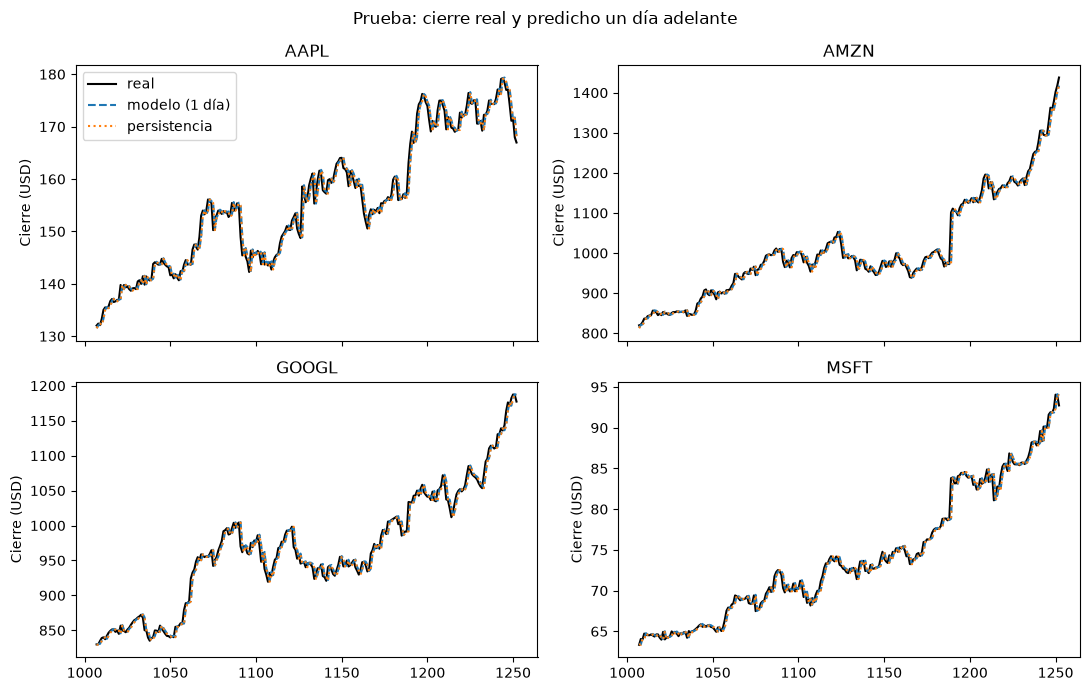

In [16]:
fig, ejes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
for eje, s in zip(ejes.ravel(), SIMBOLOS):
    eje.plot(origenes + 1, real[s][:, 0], color="black", label="real")
    eje.plot(origenes + 1, pred["modelo"][s][:, 0], linestyle="--", label="modelo (1 día)")
    eje.plot(origenes + 1, pred["persistencia"][s][:, 0], linestyle=":", label="persistencia")
    eje.set_title(s)
    eje.set_ylabel("Cierre (USD)")
ejes[0, 0].legend()
fig.suptitle("Prueba: cierre real y predicho un día adelante")
plt.tight_layout()
plt.show()

### Modelo para servir y predicción

El modelo que se usa en la aplicación se reentrena con **todas** las sesiones y los cuatro símbolos, para partir del último cierre de cada uno.

In [17]:
final = candidatos()[ganador].fit(X, y)
residuo_final = y - final.predict(X)
sigma_final = {s: float(residuo_final.xs(s, level="simbolo").std(ddof=1)) for s in SIMBOLOS}
print("retorno medio diario con todas las sesiones: %.5f" % final.named_steps["modelo"].intercept_)

filas = {}
for s in SIMBOLOS:
    est = recursiva(final, [cierres[s][-VENTANA_MINIMA:]], 7)[0]
    amp1, amp7 = np.exp(1.96 * sigma_final[s]), np.exp(1.96 * sigma_final[s] * np.sqrt(7))
    filas[s] = {"último cierre (7-feb-2018)": cierres[s][-1], "1 sesión": est[0], "rango 95 % (1)": "%.2f a %.2f" % (est[0] / amp1, est[0] * amp1),
                "7 sesiones": est[6], "rango 95 % (7)": "%.2f a %.2f" % (est[6] / amp7, est[6] * amp7)}
pd.DataFrame(filas).T.round(2)

retorno medio diario con todas las sesiones: 0.00096


,último cierre (7-feb-2018),1 sesión,rango 95 % (1),7 sesiones,rango 95 % (7)
AAPL,159.54,159.789746,155.29 a 164.42,160.924816,149.22 a 173.55
AMZN,1416.78,1417.104605,1367.53 a 1468.48,1421.756731,1293.91 a 1562.23
GOOGL,1055.41,1057.353288,1029.16 a 1086.32,1065.427845,991.91 a 1144.39
MSFT,89.61,89.72023,87.24 a 92.27,90.225729,83.77 a 97.18


La predicción para el 8 de febrero de 2018 es casi igual al último cierre. Las fechas se cuentan en días hábiles de lunes a viernes (sin descontar feriados de la bolsa), así que 7 sesiones después del 7 de febrero es el 16 de febrero.

---
# Conclusiones
---

## Resultados

Para los cuatro valores y el período 2013 a 2018, el precio de cierre se comporta, para fines de predicción con su propio historial, como un **paseo aleatorio con deriva**: ninguna variable de rezago, media móvil o volatilidad, ni los modelos de árboles, aportó nada medible sobre la deriva. El modelo entregado es un Ridge que lo reconoce (coeficientes casi en 0). Lo que aporta, más que el punto, es el **rango del 95 %** específico de cada símbolo, que fue conservador en la prueba.

Limitaciones: los datos terminan el 7 de febrero de 2018 y el modelo no conoce el precio actual. Son solo cuatro empresas tecnológicas muy grandes que subieron mucho en el período (probable selección favorable), así que la deriva estimada no es una expectativa razonable a futuro y, en un mercado bajista, el modelo seguiría prediciendo subidas. La prueba es una sola ventana, tranquila salvo el tramo final. Los símbolos están correlacionados, por lo que los orígenes de prueba no son independientes. **No es una recomendación de inversión.**

### Referencias

> Bergmeir, C., & Benítez, J. M. (2012). On the use of cross-validation for time series predictor evaluation. *Information Sciences*.
> Cont, R. (2001). Empirical properties of asset returns: Stylized facts and statistical issues. *Quantitative Finance*, 1(2), 223-236.
> Fama, E. F. (1970). Efficient capital markets: A review of theory and empirical work. *The Journal of Finance*, 25(2), 383-417.
> Künsch, H. R. (1989). The jackknife and the bootstrap for general stationary observations. *The Annals of Statistics*, 17(3), 1217-1241.
> Nugent, C. (2018). *S&P 500 stock data* [Conjunto de datos]. Kaggle.